In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
sns.set_theme()

In [26]:
plt.rcParams['font.sans-serif'] = ['KaiTi']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
data = loadmat('cluster_dataset.mat')

In [3]:
X = data['data']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

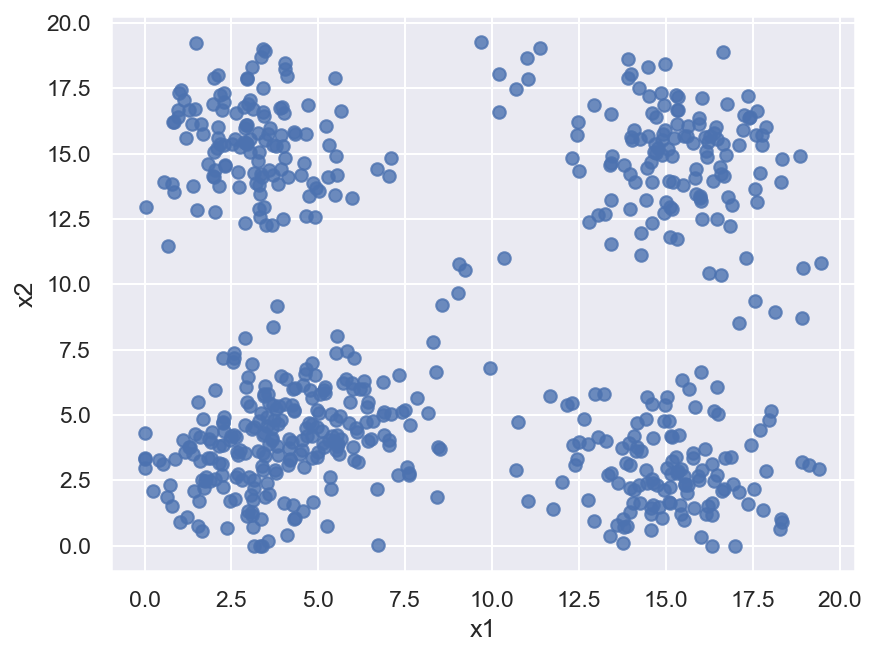

In [4]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [5]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 4

In [6]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    输出：centers：初始化的中心集（建议：元素为ndarray的list)
    可能使用的函数：random.randint
    注意：需保证随机取的样本不重复
    """
     #获取数据集总样本数量
    n_samples = X.shape[0]
    #随机生成k个不重复下标
    rand_idx = random.sample(range(n_samples), k)
    #按下标取出样本，存入列表
    centers = []
    for idx in rand_idx:
        centers.append(X[idx])
    return centers

In [7]:
#向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    """
    输入：v1:样本(ndarray), v2:当前对应的中心(ndarray)
    输出：distance:欧氏距离(float/ndarray)
    """
    #欧式距离公式
    distance = np.sqrt(np.sum((v1 - v2) ** 2))
    return distance

In [13]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心集（建议：元素为ndarray的list)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list)
    可能使用的函数：np.argmin
    注意：list和array在某些计算时的转换
    """
  #定义距离计算函数（写在函数内部，不用传参）
    def distance(a, b):
        return np.linalg.norm(a - b)  # 欧氏距离
    
    #初始化每个簇的空列表
    assignment = {}
    for i in range(len(centers)):
        assignment[i] = []
    
    #遍历每个样本，分配到最近的簇
    for sample in X:
        dis_list = []
        #计算样本到每个中心的距离
        for c in centers:
            dis = distance(sample, c)
            dis_list.append(dis)
        #找到距离最小的簇号
        cluster_idx = np.argmin(dis_list)
        #把样本加入对应簇
        assignment[cluster_idx].append(sample)
    return assignment

In [17]:
#代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心（建议：元素为ndarray的list)
    输出：cost:代价函数值（float/ndarray）
    可能使用的函数：np.argmin
    注意：list和array在使用np函数计算时的转换
    """
     #初始化变量
    total_cost = 0.0
    total_samples = 0

    #遍历每个簇
    for k_idx in range(len(centers)):
        #获取当前簇的样本列表
        cluster_samples = assignment[k_idx]
        if len(cluster_samples) == 0:
            continue  #空簇不计入代价

        #把簇内样本list转为ndarray
        cluster_samples_np = np.array(cluster_samples)
        center = centers[k_idx]

        #计算簇内所有样本到中心的欧氏距离
        distances = np.sqrt(np.sum((cluster_samples_np - center) ** 2, axis=1))
        #累加该簇的总距离和样本数
        total_cost += np.sum(distances)
        total_samples += len(cluster_samples)

    #计算平均值（处理全空簇的特殊情况）
    if total_samples == 0:
        return 0.0
    cost = total_cost / total_samples
    return cost

In [10]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    """
    输入：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), centers：当前中心（建议：元素为ndarray的list)
    输出：new_centers:更新的中心集（建议：元素为ndarray的list), stop：停机条件标识（不停机：0/停机：1）
    可能使用的函数：np.mean
    注意：list和array在使用np函数计算时的转换
    """
    new_centers = []
    stop = 0
    #遍历每一个簇
    for idx in range(len(centers)):
        #取出当前簇所有样本列表
        point_list = assignment[idx]
        #空簇直接保留原中心（k不能变）
        if len(point_list) == 0:
            new_centers.append(centers[idx])
        else:
            points_arr = np.array(point_list)
            #按列求均值得到新中心
            new_center = np.mean(points_arr, axis=0)
            new_centers.append(new_center)
    #判断新旧中心是否完全一致，一致则停机
    if np.array_equal(new_centers, centers):
        stop = 1
    return new_centers, stop

In [11]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [55]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int), max_epoch：最大训练轮数(int), plot:是否可视化（True/False)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), cost:最终的代价函数值，用于k-cost曲线的绘制（float/ndarray）
    """
     #调用1：初始化中心
    centers = init_centers(X, k)
    
    #初始化分簇字典
    assignment = {i: [] for i in range(k)}

    #迭代训练
    # _ ：是 Python里的“匿名变量”，表示我们不关心循环的具体次数，只需要它帮我们重复执行循环体里的代码就行
    #合起来：最多迭代max_epoch次，给算法一个“兜底上限”，防止它无限循环。
    for _ in range(max_epoch):   
        #调用2：样本分配
        assignment = cluster_assignment(X, centers)
        
        #调用3：更新中心+收敛判断
        centers, stop_flag = center_update(assignment, centers)
        if stop_flag == 1:
            break
    
    #调用4：调用代价函数计算最终损失
    cost = cost_function(assignment, centers)

    #可视化
    if plot:
        plt.figure()
        colors = ["r", "g", "b", "y", "m"]
        #用.items()遍历字典的键值对
        for lab, pts in assignment.items():
            if pts:  #跳过空簇
                arr = np.array(pts)
                #按簇号循环分配颜色，同时加上标签
                plt.scatter(arr[:, 0], arr[:, 1], 
                            c=colors[lab % len(colors)], 
                            label=f"簇{lab}", 
                            s=15)
        #绘制聚类中心
        cen_arr = np.array(centers)
        plt.scatter(cen_arr[:, 0], cen_arr[:, 1], 
                    s=200, c="k", marker="*", label="聚类中心")
        plt.legend()
        plt.title("K-Means聚类结果")
        plt.show()
    return assignment, cost

In [56]:
max_epoch = 200 

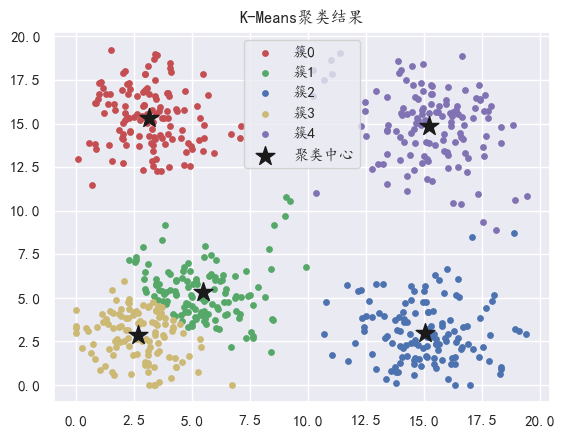

In [57]:
assignment, _ = kmeans(X, k, max_epoch)

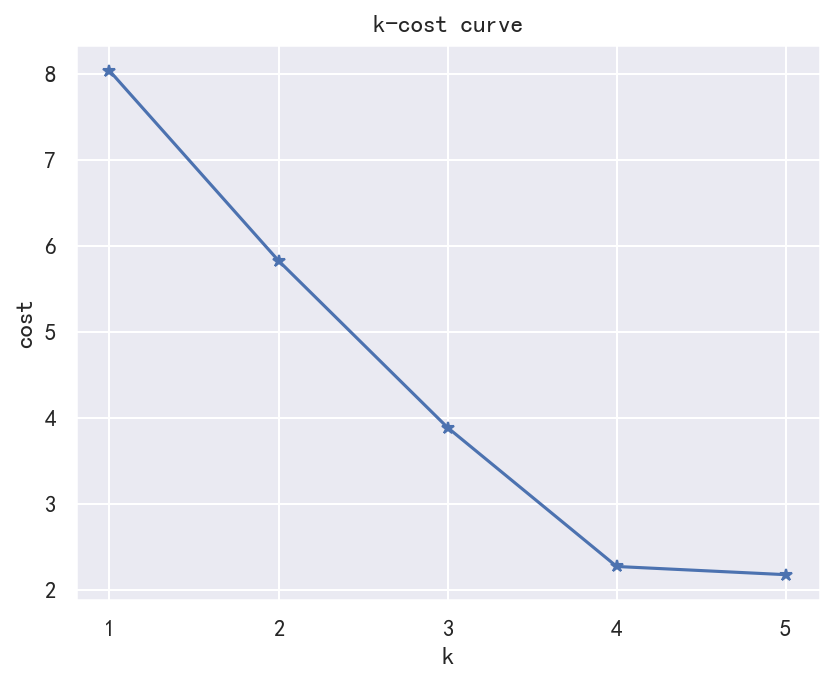

In [37]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 6
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch,False)
    Cost.append(cost)

plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()